## Cellpose segmentation for in vitro HEK cells

This script performs automated cell segmentation on in vitro HEK cell datasets using the Cellpose framework. The workflow uses already maximum-intensity-projected images organized into two experimental folders, then applies Cellpose segmentation to a user-defined reference channel.

The generated masks are saved in a separate mask folder that preserves the input folder hierarchy. These masks are then applied to the two channels, and for each segmented region the corresponding signals are extracted to compute a ratio readout.
The resulting outputs include segmented cell masks, per-cell ratio values, filtering summaries, and final quality-control plots, enabling quantitative analysis of ratio fluorescence signals in vitro.

### Required packages

This workflow relies on standard Python libraries for image handling, plotting, tabular output, signal processing, and Cellpose-based segmentation. Required packages can be installed with:

```bash
pip install numpy pandas matplotlib seaborn tifffile scikit-image scipy opencv-python cellpose

In [1]:
from pathlib import Path
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile as tiff
from cellpose import models
from skimage import exposure
from skimage.color import label2rgb



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	linux 
python version: 	3.10.18 
torch version:  	2.5.1+cu121! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




### Input structure and analysis settings

The analysis starts from already projected MIP images. The input folder must contain two condition folders, named `condition1` and `condition2`. Inside each condition, the script searches recursively for folders containing both channel images, `ch00` and `ch01`. Each folder containing the two channels is treated as one field of view.
The Cellpose segmentation channel, ratio numerator, and ratio denominator are defined below. Change only these variables if the segmentation channel or ratio direction needs to be changed.
Output files are saved outside the input image folder. Cellpose masks are stored in `example_masks_MIP_images`, with one folder per condition, and all CSV tables and plots are stored in `output`.

In [2]:
root_dir = Path("./example_MIP_images")
mask_root_dir = root_dir.parent / "example_masks_MIP_images"
output_dir = root_dir.parent / "output_cells_analysis"

conditions = ["condition1", "condition2"]
channels = ["ch00", "ch01"]

segmentation_channel = "ch00"      
numerator_channel = "ch01"       
denominator_channel = "ch00"     

saturation_value = 255
max_saturated_fraction = 0.01
min_denominator_signal_to_noise = 3

mask_root_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

print("Conditions:", conditions)
print("Segmentation channel:", segmentation_channel)
print("Ratio:", f"{numerator_channel}/{denominator_channel}")

Conditions: ['condition1', 'condition2']
Segmentation channel: ch00
Ratio: ch01/ch00


### File discovery

For each condition, all subfolders are inspected and folders containing both `ch00` and `ch01` TIFF images are retained for analysis. This allows the input structure to contain only condition folders, or additional nested folders if needed, without requiring pH-based subfolders. The relative folder structure from the input data is preserved in the mask output folder.

In [3]:
def find_channel_file(folder, channel):
    matches = [
        p for p in folder.iterdir()
        if p.is_file()
        and p.suffix.lower() in [".tif", ".tiff"]
        and channel.lower() in p.name.lower()
    ]
    if not matches:
        return None
    mip_matches = [p for p in matches if "mip" in p.name.lower()]
    return mip_matches[0] if mip_matches else matches[0]

def discover_image_pairs(root_dir, conditions, channels):
    records = []
    for condition in conditions:
        condition_root = root_dir / condition
        candidate_dirs = [condition_root] + [p for p in condition_root.rglob("*") if p.is_dir()]
        for folder in candidate_dirs:
            files = {channel: find_channel_file(folder, channel) for channel in channels}
            if not all(files.values()):
                continue
            rel_path = folder.relative_to(condition_root)
            rel_path_str = "." if str(rel_path) == "." else str(rel_path)
            records.append({
                "condition": condition,
                "folder": folder,
                "rel_path": rel_path_str,
                **files
            })
    return records

image_pairs = discover_image_pairs(root_dir, conditions, channels)

print(f"Found {len(image_pairs)} image pairs")
for r in image_pairs[:30]:
    print(r["condition"], "|", r["rel_path"], "|", r["ch00"].name, "|", r["ch01"].name)

Found 18 image pairs
condition1 | pH_n3/view3 | ch00_MIP.tif | ch01_MIP.tif
condition1 | pH_n3/view1 | ch00_MIP.tif | ch01_MIP.tif
condition1 | pH_n3/view2 | ch00_MIP.tif | ch01_MIP.tif
condition1 | pH_n1/view3 | ch00_MIP.tif | ch01_MIP.tif
condition1 | pH_n1/view1 | ch00_MIP.tif | ch01_MIP.tif
condition1 | pH_n1/view2 | ch00_MIP.tif | ch01_MIP.tif
condition1 | pH_n2/view3 | ch00_MIP.tif | ch01_MIP.tif
condition1 | pH_n2/view1 | ch00_MIP.tif | ch01_MIP.tif
condition1 | pH_n2/view2 | ch00_MIP.tif | ch01_MIP.tif
condition2 | pH_n3/view3 | ch00_MIP.tif | ch01_MIP.tif
condition2 | pH_n3/view1 | ch00_MIP.tif | ch01_MIP.tif
condition2 | pH_n3/view2 | ch00_MIP.tif | ch01_MIP.tif
condition2 | pH_n1/view3 | ch00_MIP.tif | ch01_MIP.tif
condition2 | pH_n1/view1 | ch00_MIP.tif | ch01_MIP.tif
condition2 | pH_n1/view2 | ch00_MIP.tif | ch01_MIP.tif
condition2 | pH_n2/view3 | ch00_MIP.tif | ch01_MIP.tif
condition2 | pH_n2/view1 | ch00_MIP.tif | ch01_MIP.tif
condition2 | pH_n2/view2 | ch00_MIP.tif | ch

### Cellpose segmentation on MIP images

Maximum-intensity projection images are segmented using Cellpose (Stringer et al., 2021 [1]). For each experimental condition, the script uses the selected reference channel and saves the resulting label mask as a NumPy array. A visualization overlay is also generated by superimposing the segmentation labels onto the normalized MIP image.
Segmentation results are stored in condition-specific output directories inside `example_masks_MIP_images`. The original field-of-view folder hierarchy is preserved so each mask can be matched directly to the corresponding channel images.

In [11]:
model = models.CellposeModel(gpu= True)

def mask_output_folder(condition, rel_path):
    folder = mask_root_dir / f"{condition}_mask"
    if rel_path != ".":
        folder = folder / rel_path
    return folder

def run_cellpose(mip_path, save_folder):
    img = tiff.imread(mip_path).astype(np.float32)

    result = model.eval(
        [img],
        diameter=None,
        normalize=True,
        invert=False,
        progress=True,
    )

    masks = result[0]
    mask = masks[0].astype(np.int32)
    n_cells = mask.max()

    os.makedirs(save_folder, exist_ok=True)

    base = os.path.splitext(os.path.basename(mip_path))[0]

    np.save(os.path.join(save_folder, f"{base}_labels.npy"), mask)

    img_norm = exposure.rescale_intensity(img, in_range="image", out_range=(0, 1))
    overlay = label2rgb(mask, image=img_norm, alpha=0.4, bg_label=0)
    plt.imsave(os.path.join(save_folder, f"{base}_overlay.png"), np.clip(overlay, 0, 1))

    print(f"Saved: {save_folder} | cells: {n_cells}")

for record in image_pairs:
    condition = record["condition"]
    rel_path = record["rel_path"]
    mip_path = record[segmentation_channel]
    save_folder = mask_output_folder(condition, rel_path)

    print("Running:", mip_path)
    run_cellpose(mip_path, save_folder)

print("Done.")

Running: example_MIP_images/condition1/pH_n3/view3/ch00_MIP.tif
Saved: example_masks_MIP_images/condition1_mask/pH_n3/view3 | cells: 143
Running: example_MIP_images/condition1/pH_n3/view1/ch00_MIP.tif
Saved: example_masks_MIP_images/condition1_mask/pH_n3/view1 | cells: 138
Running: example_MIP_images/condition1/pH_n3/view2/ch00_MIP.tif
Saved: example_masks_MIP_images/condition1_mask/pH_n3/view2 | cells: 164
Running: example_MIP_images/condition1/pH_n1/view3/ch00_MIP.tif
Saved: example_masks_MIP_images/condition1_mask/pH_n1/view3 | cells: 102
Running: example_MIP_images/condition1/pH_n1/view1/ch00_MIP.tif
Saved: example_masks_MIP_images/condition1_mask/pH_n1/view1 | cells: 94
Running: example_MIP_images/condition1/pH_n1/view2/ch00_MIP.tif
Saved: example_masks_MIP_images/condition1_mask/pH_n1/view2 | cells: 86
Running: example_MIP_images/condition1/pH_n2/view3/ch00_MIP.tif
Saved: example_masks_MIP_images/condition1_mask/pH_n2/view3 | cells: 133
Running: example_MIP_images/condition1/pH_n

### Single-cell intensity filtering, quality control, and ratio extraction

For each condition and field of view, background-corrected single-cell fluorescence intensities are extracted from the channel MIP images using the Cellpose-derived segmentation masks. Background signal in each channel is estimated from pixels outside labeled cells and subtracted prior to quantification. Mean intensities are then calculated for every segmented cell, together with associated metadata including condition, folder, view, and cell area.
To ensure robust ratio measurements, several filtering criteria are applied at the single-cell level. Cells are excluded if the denominator channel is too dim relative to background noise, if more than 1% of pixels are saturated in either channel, or if the background-corrected denominator intensity is non-positive. For cells passing these criteria, the fluorescence ratio is computed and retained for downstream analysis.
The analysis produces three output tables: filtered single-cell ratios, raw single-cell intensities prior to filtering, and a per-image summary of filtering outcomes. All tables are saved in the `output` folder.

In [9]:
rows = []
summary = []
raw_rows = []

def extract_view(rel_path):
    m = re.search(r"(view\d+)", str(rel_path), re.IGNORECASE)
    return m.group(1) if m else str(rel_path)

def load_mask(mask_dir, segmentation_channel):
    label_files = [f for f in os.listdir(mask_dir) if f.endswith("_labels.npy") and segmentation_channel in f]
    if len(label_files) == 0:
        label_files = [f for f in os.listdir(mask_dir) if f.endswith("_labels.npy")]
    if len(label_files) == 0:
        return None
    if len(label_files) > 1:
        print(f"More than one mask found in {mask_dir}; using {label_files[0]}")
    return os.path.join(mask_dir, label_files[0])

for record in image_pairs:
    condition = record["condition"]
    rel_path = record["rel_path"]
    view_value = extract_view(rel_path)

    mask_dir = mask_output_folder(condition, rel_path)

    if not mask_dir.is_dir():
        print("Missing mask folder:", mask_dir)
        continue

    label_path = load_mask(mask_dir, segmentation_channel)
    if label_path is None:
        print("Missing mask file:", mask_dir)
        continue

    frames = {channel: tiff.imread(record[channel]).astype(np.float32) for channel in channels}
    labels = np.load(label_path).astype(np.int32)

    if any(frame.shape != labels.shape for frame in frames.values()):
        print("Shape mismatch:", condition, rel_path)
        continue

    bg_mask = labels == 0
    if np.sum(bg_mask) == 0:
        print("No background pixels:", condition, rel_path)
        continue

    bg = {channel: np.median(frames[channel][bg_mask]) for channel in channels}

    denom_bg_pixels = frames[denominator_channel][bg_mask]
    denom_bg = np.median(denom_bg_pixels)
    mad = np.median(np.abs(denom_bg_pixels - denom_bg))
    denom_noise = 1.4826 * mad

    if denom_noise <= 0:
        lo, hi = np.percentile(denom_bg_pixels, [5, 95])
        clipped = denom_bg_pixels[(denom_bg_pixels >= lo) & (denom_bg_pixels <= hi)]
        denom_noise = np.std(clipped)

    if denom_noise <= 0:
        denom_noise = np.std(denom_bg_pixels)

    n_total = 0
    n_kept = 0
    n_dim = 0
    n_sat = 0
    n_bad_den = 0

    for cell_id in np.unique(labels):
        if cell_id == 0:
            continue

        cell_mask = labels == cell_id
        n_total += 1

        pix = {channel: frames[channel][cell_mask] for channel in channels}
        corr = {channel: pix[channel] - bg[channel] for channel in channels}
        means = {channel: corr[channel].mean() for channel in channels}

        raw_rows.append({
            "condition": condition,
            "folder": rel_path,
            "view": view_value,
            "cell_id": int(cell_id),
            "ch00_mean": float(means["ch00"]),
            "ch01_mean": float(means["ch01"]),
            "area_px": int(cell_mask.sum())
        })

        denominator_mean = means[denominator_channel]

        if denominator_mean < min_denominator_signal_to_noise * denom_noise:
            n_dim += 1
            continue

        if any(np.mean(pix[channel] >= saturation_value) > max_saturated_fraction for channel in channels):
            n_sat += 1
            continue

        if denominator_mean <= 0:
            n_bad_den += 1
            continue

        ratio = means[numerator_channel] / denominator_mean

        rows.append({
            "condition": condition,
            "folder": rel_path,
            "view": view_value,
            "cell_id": int(cell_id),
            "ch00_mean": float(means["ch00"]),
            "ch01_mean": float(means["ch01"]),
            f"ratio_{numerator_channel}_over_{denominator_channel}": float(ratio),
            "area_px": int(cell_mask.sum())
        })

        n_kept += 1

    print(f"{condition} | {rel_path} | total={n_total} kept={n_kept} dim={n_dim} sat={n_sat} bad_den={n_bad_den}")

    summary.append({
        "condition": condition,
        "folder": rel_path,
        "view": view_value,
        "n_total": n_total,
        "n_kept": n_kept,
        "n_dim_removed": n_dim,
        "n_sat_removed": n_sat,
        "n_bad_den": n_bad_den
    })

df = pd.DataFrame(rows)
df.to_csv(output_dir / "single_cell_ratios.csv", index=False)

df_sum = pd.DataFrame(summary)
df_sum.to_csv(output_dir / "filtering_summary.csv", index=False)

df_raw = pd.DataFrame(raw_rows)
df_raw.to_csv(output_dir / "single_cell_raw_before_filtering.csv", index=False)

print("Saved:", output_dir / "single_cell_ratios.csv")
print("Saved:", output_dir / "filtering_summary.csv")
print("Saved:", output_dir / "single_cell_raw_before_filtering.csv")

df.head()

condition1 | pH_n3/view3 | total=143 kept=122 dim=20 sat=1 bad_den=0
condition1 | pH_n3/view1 | total=138 kept=126 dim=12 sat=0 bad_den=0
condition1 | pH_n3/view2 | total=164 kept=136 dim=28 sat=0 bad_den=0
condition1 | pH_n1/view3 | total=102 kept=75 dim=27 sat=0 bad_den=0
condition1 | pH_n1/view1 | total=94 kept=72 dim=22 sat=0 bad_den=0
condition1 | pH_n1/view2 | total=86 kept=68 dim=18 sat=0 bad_den=0
condition1 | pH_n2/view3 | total=133 kept=101 dim=31 sat=1 bad_den=0
condition1 | pH_n2/view1 | total=85 kept=67 dim=18 sat=0 bad_den=0
condition1 | pH_n2/view2 | total=71 kept=61 dim=10 sat=0 bad_den=0
condition2 | pH_n3/view3 | total=63 kept=52 dim=11 sat=0 bad_den=0
condition2 | pH_n3/view1 | total=68 kept=59 dim=9 sat=0 bad_den=0
condition2 | pH_n3/view2 | total=68 kept=63 dim=5 sat=0 bad_den=0
condition2 | pH_n1/view3 | total=62 kept=56 dim=6 sat=0 bad_den=0
condition2 | pH_n1/view1 | total=53 kept=45 dim=8 sat=0 bad_den=0
condition2 | pH_n1/view2 | total=75 kept=57 dim=18 sat=0 

,condition,folder,view,cell_id,ch00_mean,ch01_mean,ratio_ch01_over_ch00,area_px
0,condition1,pH_n3/view3,view3,4,5.393939,10.101010,1.872659,99
1,condition1,pH_n3/view3,view3,5,12.081272,22.038870,1.824218,283
2,condition1,pH_n3/view3,view3,6,4.264151,13.301887,3.119469,212
3,condition1,pH_n3/view3,view3,7,4.081818,8.363636,2.048998,110
4,condition1,pH_n3/view3,view3,8,7.184931,14.075342,1.959009,146


### Quality-control histograms and final plots

Condition-specific histograms compare raw single-cell channel intensities before and after filtering. The plots are displayed in the notebook and saved in the `output` folder for reuse in figures or reports.

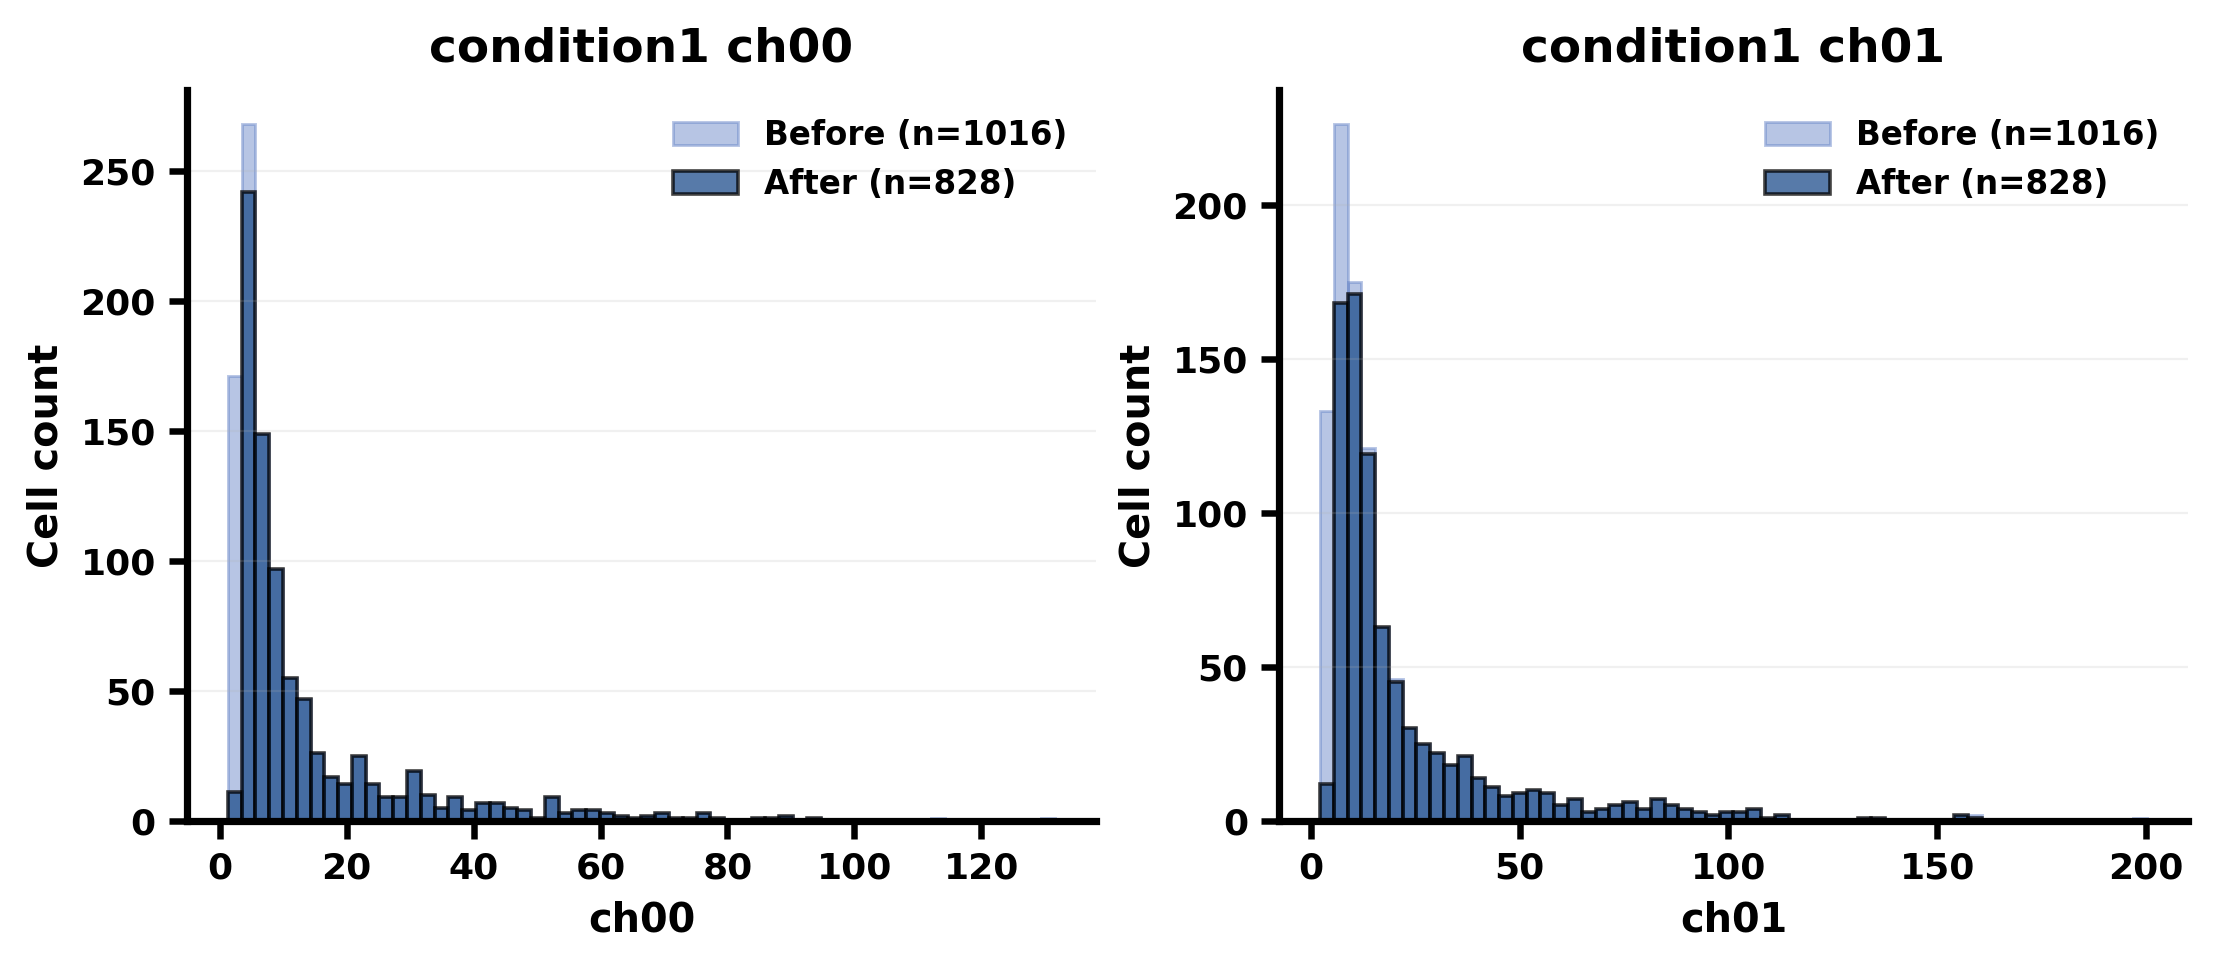

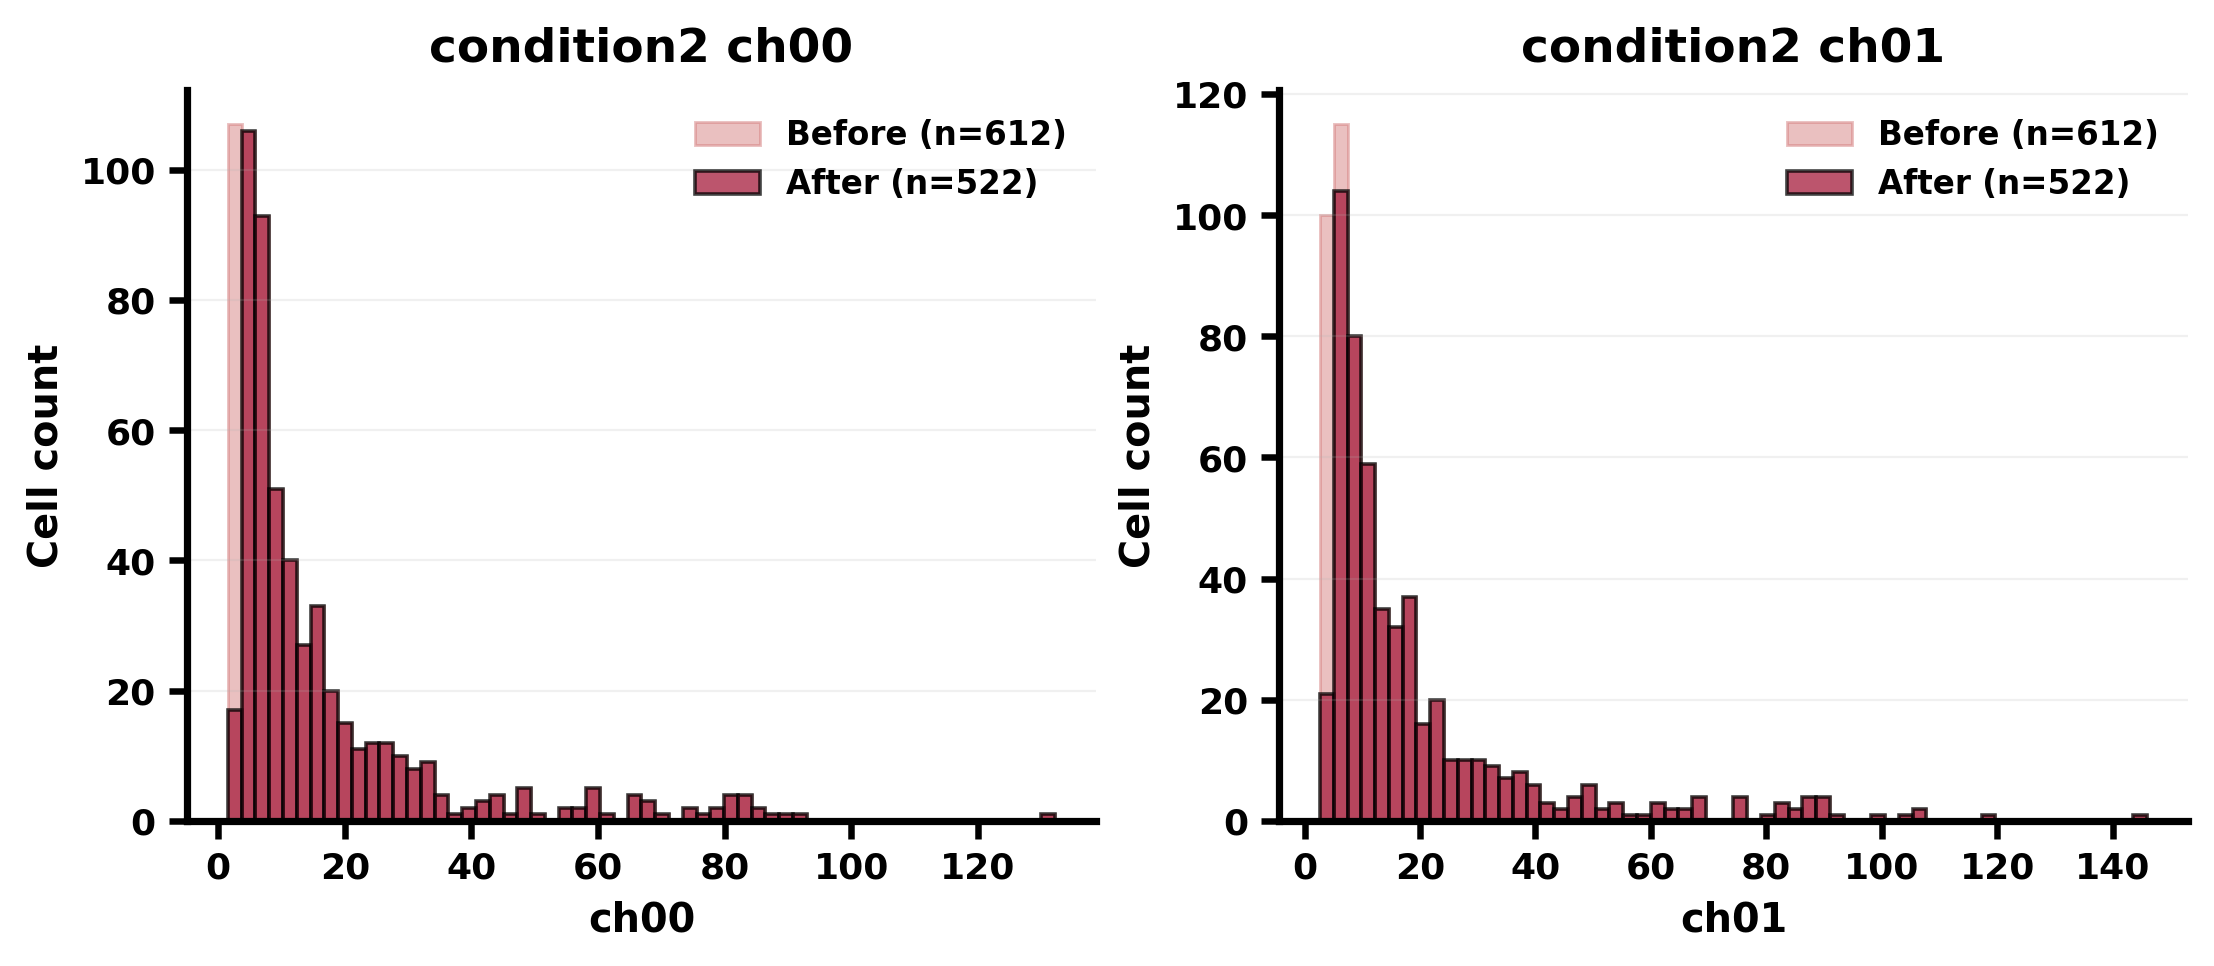

In [10]:
def style_prism(ax, title, xlabel, ylabel="Cell count"):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11, fontweight="bold")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2.0)
    ax.spines["bottom"].set_linewidth(2.0)

    ax.tick_params(axis="both", which="major", width=1.8, length=5, labelsize=10)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")

    ax.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.18)
    ax.set_facecolor("white")

def overlay_hist(ax, before_vals, after_vals, bins, title, xlabel, before_color, after_color):
    ax.hist(before_vals, bins=bins, alpha=0.45, color=before_color, edgecolor=before_color, linewidth=0.8, label=f"Before (n={len(before_vals)})")
    ax.hist(after_vals, bins=bins, alpha=0.75, color=after_color, edgecolor="black", linewidth=1.0, label=f"After (n={len(after_vals)})")
    style_prism(ax, title=title, xlabel=xlabel)
    leg = ax.legend(frameon=False, fontsize=9, loc="upper right")
    for text in leg.get_texts():
        text.set_fontweight("bold")

colors = {
    "condition1_before": "#6080C5",
    "condition1_after":  "#1F4E8C",
    "condition2_before": "#D17474",
    "condition2_after":  "#A61C3C",
}

n_bins = 60

for cond in conditions:
    fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.6), dpi=260, constrained_layout=True)

    for ax, col, label in zip(axes, ["ch00_mean", "ch01_mean"], ["ch00", "ch01"]):
        before_vals = df_raw.loc[df_raw["condition"] == cond, col].dropna().values
        after_vals = df.loc[df["condition"] == cond, col].dropna().values

        if len(before_vals) == 0 and len(after_vals) == 0:
            ax.set_visible(False)
            continue

        combined = np.concatenate([
            before_vals if len(before_vals) > 0 else np.array([]),
            after_vals if len(after_vals) > 0 else np.array([])
        ])

        x_min = np.min(combined)
        x_max = np.max(combined)

        if x_min == x_max:
            x_min -= 0.5
            x_max += 0.5

        bins = np.linspace(x_min, x_max, n_bins + 1)

        overlay_hist(
            ax=ax,
            before_vals=before_vals,
            after_vals=after_vals,
            bins=bins,
            title=f"{cond} {label}",
            xlabel=label,
            before_color=colors[f"{cond}_before"],
            after_color=colors[f"{cond}_after"]
        )

    fig.savefig(output_dir / f"{cond}_histograms.png", dpi=300, bbox_inches="tight")
    fig.savefig(output_dir / f"{cond}_histograms.pdf", bbox_inches="tight")
    plt.show()

## References

1. Stringer C, Wang T, Michaelos M, Pachitariu M. Cellpose: a generalist algorithm for cellular segmentation. Nature Methods. 2021;18:100–106. 
